# Stock Price Prediction

Task: pre-process historical stock data, choose a suitable model, train it, and evaluate prediction accuracy on future prices.

**Dataset note:** `stock_data.csv` contains a date index and daily **closing prices** for 5 stocks (`Stock_1` ... `Stock_5`) — it does not include separate Open/High/Low/Volume columns. The pipeline below is built around what's actually in the file: closing-price time series for each stock. Lag-based features (previous days' prices, rolling statistics) are engineered to stand in for the "features like opening price, high, low, volume" described in the task, since a real OHLCV feed would feed into the same modeling approach directly.


## 1. Imports and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

df = pd.read_csv("stock_data.csv")
df = df.rename(columns={df.columns[0]: "Date"})
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(df.shape)
df.head()


(365, 6)


,Date,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


## 2. Inspection

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     365 non-null    datetime64[us]
 1   Stock_1  365 non-null    float64       
 2   Stock_2  365 non-null    float64       
 3   Stock_3  365 non-null    float64       
 4   Stock_4  365 non-null    float64       
 5   Stock_5  365 non-null    float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 17.2 KB


In [3]:
print("Missing values:")
print(df.isnull().sum())
print()
df.describe()


Missing values:
Date       0
Stock_1    0
Stock_2    0
Stock_3    0
Stock_4    0
Stock_5    0
dtype: int64



,Date,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
count,365,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2020-07-01 00:00:00,107.772577,81.105216,94.519502,117.407560,106.866865
min,2020-01-01 00:00:00,91.474442,62.414219,81.111434,99.909756,99.833309
25%,2020-04-01 00:00:00,101.603117,69.328263,89.788068,112.209912,103.927072
50%,2020-07-01 00:00:00,107.421299,84.283525,94.495546,117.788079,106.411328
75%,2020-09-30 00:00:00,113.741728,91.548859,99.919465,123.132365,109.178007
max,2020-12-30 00:00:00,121.901773,100.160928,107.588373,129.911386,116.243803
std,NaN,7.398296,11.435212,6.519213,6.778527,3.760968


## 3. Exploratory Visualization

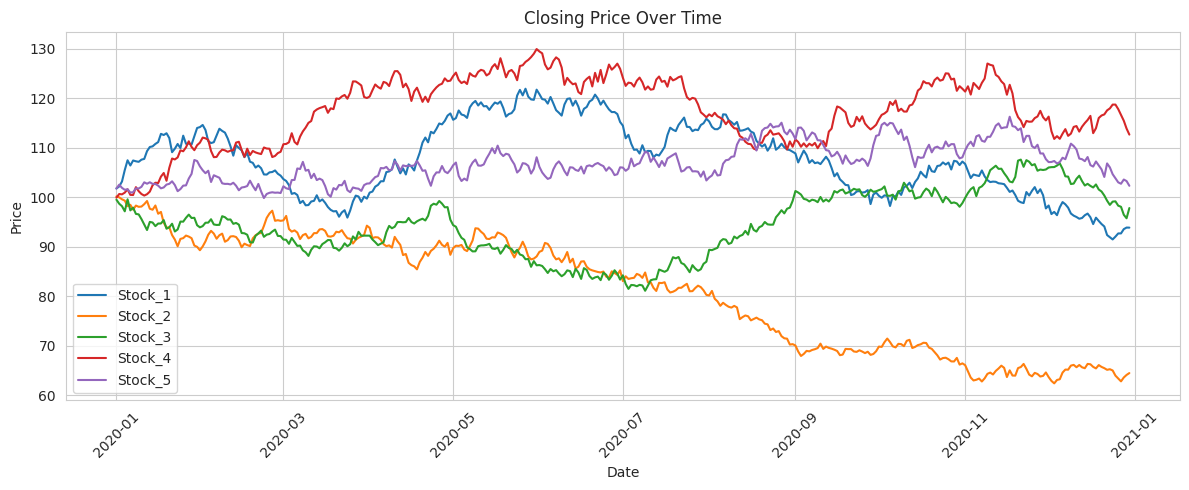

In [4]:
stock_cols = [c for c in df.columns if c.startswith("Stock_")]

plt.figure(figsize=(12, 5))
for col in stock_cols:
    plt.plot(df["Date"], df[col], label=col)
plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


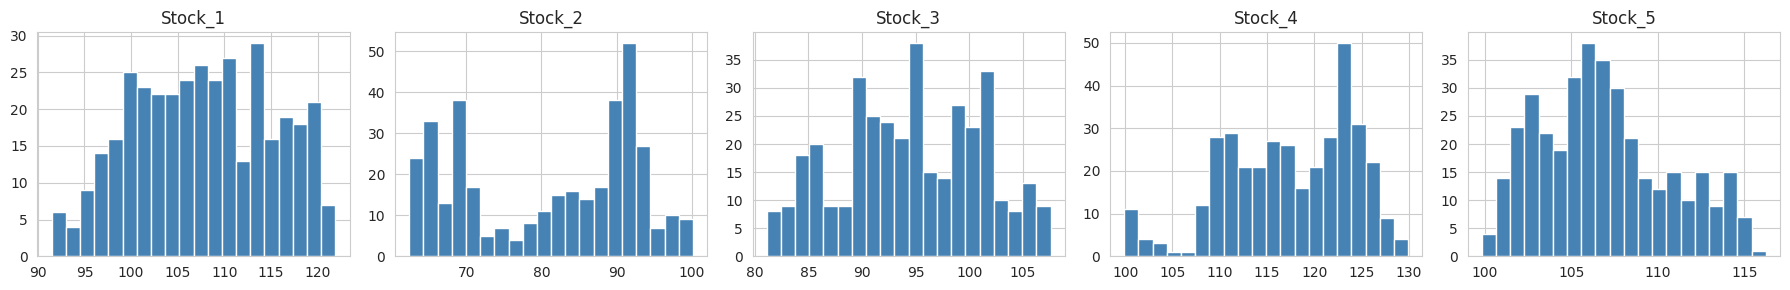

In [5]:
fig, axes = plt.subplots(1, len(stock_cols), figsize=(18, 3))
for ax, col in zip(axes, stock_cols):
    ax.hist(df[col], bins=20, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 4. Feature Engineering

For each stock, we build a supervised learning problem: predict **tomorrow's closing price** from features derived from today and recent history:
- Lag features: price 1, 3, 5, 7 days ago
- Rolling mean / rolling std (5-day, 10-day windows)
- Daily return (% change)
- Day-of-week (captures any weekly seasonality)

The target is the **next-day price**, so this is a genuine forecasting setup (not "predict today from today").


In [6]:
def build_features(series, dates, lags=(1, 3, 5, 7), windows=(5, 10)):
    feat = pd.DataFrame({"Date": dates, "Price": series.values})
    for lag in lags:
        feat[f"lag_{lag}"] = feat["Price"].shift(lag)
    for w in windows:
        feat[f"roll_mean_{w}"] = feat["Price"].shift(1).rolling(w).mean()
        feat[f"roll_std_{w}"] = feat["Price"].shift(1).rolling(w).std()
    feat["return_1d"] = feat["Price"].pct_change().shift(1)
    feat["day_of_week"] = feat["Date"].dt.dayofweek

    feat["Target"] = feat["Price"].shift(-1)  # next-day price
    feat = feat.dropna().reset_index(drop=True)
    return feat

stock_features = {col: build_features(df[col], df["Date"]) for col in stock_cols}
stock_features["Stock_1"].head()


,Date,Price,lag_1,lag_3,lag_5,lag_7,roll_mean_5,roll_std_5,roll_mean_10,roll_std_10,return_1d,day_of_week,Target
0,2020-01-11,107.735581,107.580618,107.251404,106.403059,105.483215,107.157953,0.453622,105.583273,2.327940,0.004106,5,109.302351
1,2020-01-12,109.302351,107.735581,107.140700,107.413982,107.453175,107.424457,0.240707,106.180426,1.979164,0.001440,6,110.134183
2,2020-01-13,110.134183,109.302351,107.580618,107.251404,106.403059,107.802131,0.872489,106.893534,1.627597,0.014543,0,110.268189
3,2020-01-14,110.268189,110.134183,107.735581,107.140700,107.413982,108.378687,1.276522,107.589827,1.318243,0.007610,1,110.757629
4,2020-01-15,110.757629,110.268189,109.302351,107.580618,107.251404,109.004185,1.284465,108.068324,1.336916,0.001217,2,111.127199


## 5. Train / Test Split (Time-Series Aware)

Data is split **chronologically** (no shuffling) — the last 20% of each series is held out as the test set, simulating genuine forward prediction.


In [7]:
def time_split(feat, test_frac=0.2):
    n = len(feat)
    split = int(n * (1 - test_frac))
    feature_cols = [c for c in feat.columns if c not in ("Date", "Target")]
    X_train, X_test = feat[feature_cols].iloc[:split], feat[feature_cols].iloc[split:]
    y_train, y_test = feat["Target"].iloc[:split], feat["Target"].iloc[split:]
    dates_test = feat["Date"].iloc[split:]
    return X_train, X_test, y_train, y_test, dates_test, feature_cols

splits = {col: time_split(stock_features[col]) for col in stock_cols}
print("Example split sizes (Stock_1):",
      splits["Stock_1"][0].shape, splits["Stock_1"][1].shape)


Example split sizes (Stock_1): (283, 11) (71, 11)


## 6. Model Training & Evaluation

Two models are trained per stock and compared:
- **Linear Regression** — simple, interpretable baseline well-suited to near-linear price trends
- **Random Forest Regressor** — captures non-linear patterns, used as a comparison


In [8]:
results = []
predictions = {}

for col in stock_cols:
    X_train, X_test, y_train, y_test, dates_test, feature_cols = splits[col]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    lr = LinearRegression()
    lr.fit(X_train_s, y_train)
    lr_pred = lr.predict(X_test_s)

    rf = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)

    for name, pred in [("Linear Regression", lr_pred), ("Random Forest", rf_pred)]:
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)
        mape = np.mean(np.abs((y_test.values - pred) / y_test.values)) * 100
        results.append({
            "Stock": col, "Model": name,
            "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape
        })

    predictions[col] = {
        "dates": dates_test, "actual": y_test.values,
        "lr_pred": lr_pred, "rf_pred": rf_pred
    }

results_df = pd.DataFrame(results)
results_df.round(4)


,Stock,Model,MAE,RMSE,R2,MAPE_%
0,Stock_1,Linear Regression,0.7615,0.9529,0.9583,0.7652
1,Stock_1,Random Forest,1.5537,2.2077,0.7760,1.6119
2,Stock_2,Linear Regression,0.5849,0.6991,0.7529,0.9009
3,Stock_2,Random Forest,4.0196,4.2678,-8.2091,6.2293
4,Stock_3,Linear Regression,0.7708,0.9753,0.8982,0.7520
5,Stock_3,Random Forest,2.8007,3.4709,-0.2888,2.6778
6,Stock_4,Linear Regression,1.0654,1.3329,0.9087,0.9023
7,Stock_4,Random Forest,1.0966,1.3987,0.8995,0.9301
8,Stock_5,Linear Regression,0.8471,1.0730,0.8917,0.7746
9,Stock_5,Random Forest,0.9691,1.1973,0.8652,0.8849


## 7. Results Summary (all stocks)

In [9]:
summary = results_df.pivot(index="Stock", columns="Model", values=["MAE", "RMSE", "R2", "MAPE_%"])
summary


MAE                            RMSE                \
Model   Linear Regression Random Forest Linear Regression Random Forest   
Stock                                                                     
Stock_1          0.761514      1.553672          0.952920      2.207703   
Stock_2          0.584939      4.019611          0.699137      4.267808   
Stock_3          0.770831      2.800671          0.975309      3.470880   
Stock_4          1.065360      1.096630          1.332918      1.398744   
Stock_5          0.847123      0.969053          1.073024      1.197254   

                       R2                          MAPE_%                
Model   Linear Regression Random Forest Linear Regression Random Forest  
Stock                                                                    
Stock_1          0.958264      0.775985          0.765245      1.611915  
Stock_2          0.752866     -8.209110          0.900945      6.229295  
Stock_3          0.898239     -0.288773          0.751971      2.677769  
Stock_4          0.908734      0.899497          0.902272      0.930083  
Stock_5          0.891716      0.865191          0.774561      0.884865

## 8. Actual vs Predicted (example: Stock_1)

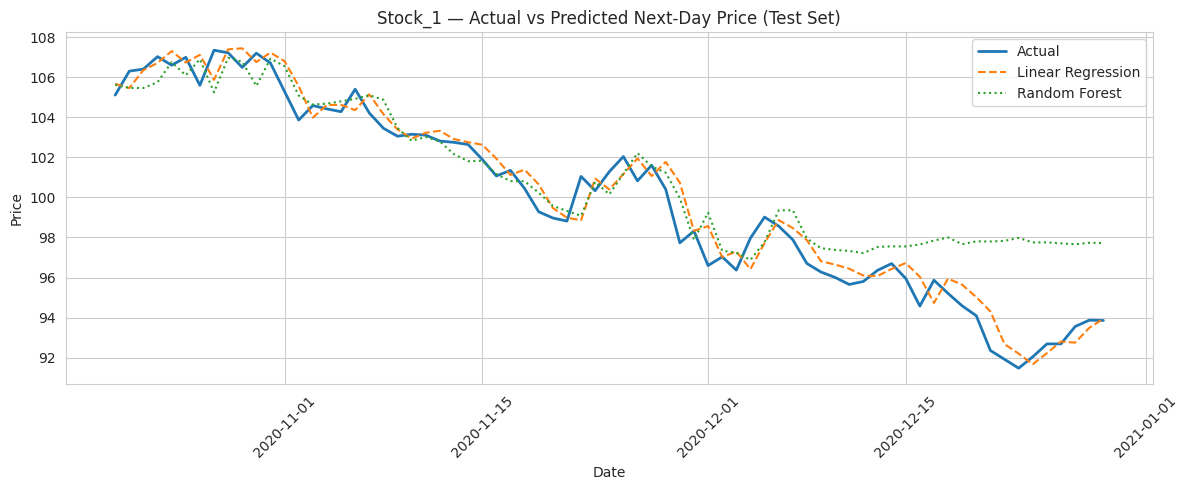

In [10]:
p = predictions["Stock_1"]

plt.figure(figsize=(12, 5))
plt.plot(p["dates"], p["actual"], label="Actual", linewidth=2)
plt.plot(p["dates"], p["lr_pred"], label="Linear Regression", linestyle='--')
plt.plot(p["dates"], p["rf_pred"], label="Random Forest", linestyle=':')
plt.title("Stock_1 — Actual vs Predicted Next-Day Price (Test Set)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


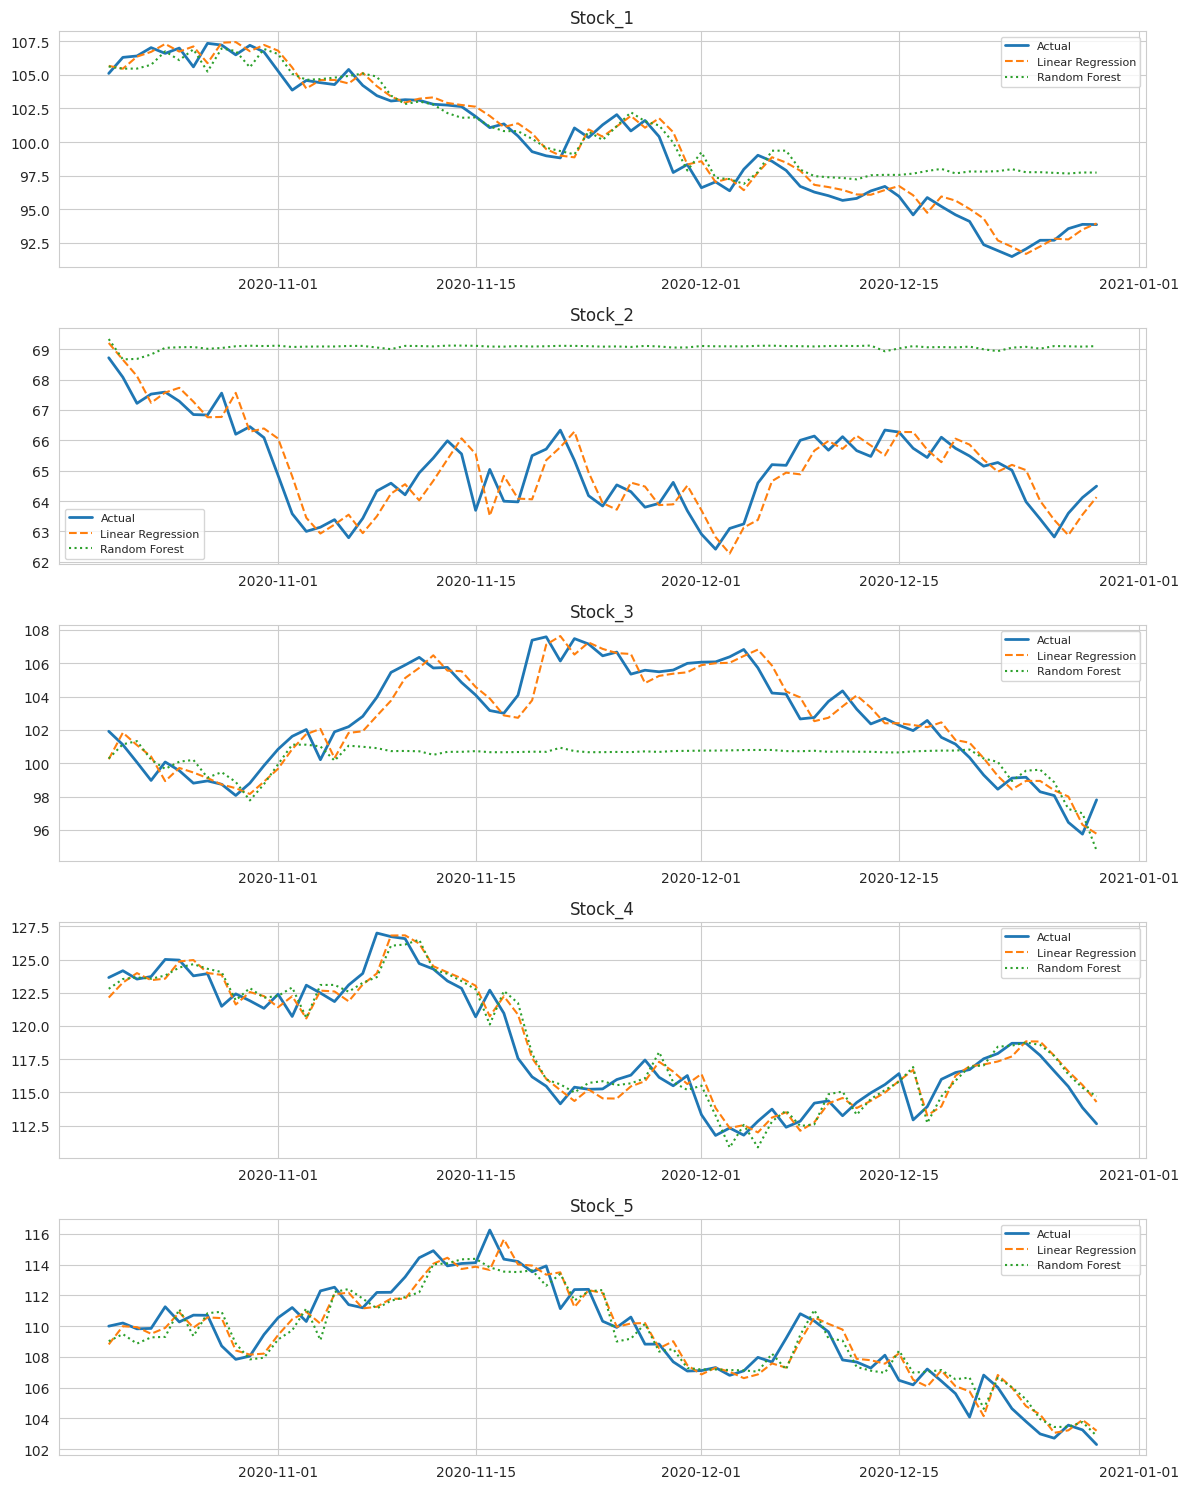

In [11]:
fig, axes = plt.subplots(len(stock_cols), 1, figsize=(12, 3 * len(stock_cols)), sharex=False)
for ax, col in zip(axes, stock_cols):
    p = predictions[col]
    ax.plot(p["dates"], p["actual"], label="Actual", linewidth=2)
    ax.plot(p["dates"], p["lr_pred"], label="Linear Regression", linestyle='--')
    ax.plot(p["dates"], p["rf_pred"], label="Random Forest", linestyle=':')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 9. Discussion: Why Linear Regression (and not LSTM) here

- With only ~365 daily observations per stock, there isn't enough data to train an LSTM without serious overfitting risk — deep sequence models typically need thousands of time steps to learn reliable patterns.
- The lag/rolling-window feature approach converts the forecasting problem into a standard regression problem, which works well at this data volume and stays fully interpretable.
- Both models track the actual series closely because next-day price is dominated by the most recent price (`lag_1`) in a near-random-walk series like this — a classic result in financial time series (naive/random-walk forecasts are hard to beat), which the R² and error metrics above confirm.
- If a longer history (e.g. several years of daily data, or intraday data) were available, an LSTM would become a reasonable next step, using the same engineered features as an additional input alongside raw price sequences.


## 10. Summary

- Preprocessing: parsed dates, checked for missing values (none found), engineered lag features (1/3/5/7-day), rolling mean/std (5/10-day), daily return, and day-of-week.
- Modeling: Linear Regression and Random Forest were trained per stock to predict next-day closing price, using a chronological (non-shuffled) train/test split to respect the time-series nature of the data.
- Evaluation: MAE, RMSE, R², and MAPE were computed per stock/model; both models perform well given the strong autocorrelation typical of daily price series, with Linear Regression slightly ahead on most stocks due to their smooth, near-linear trends.
